# Downloading Animals-10 dataset
Downloading dataset with script `./src/load_data.py`

Source dataset: \
https://huggingface.co/datasets/Rapidata/Animals-10

In [2]:
from src.load_data import save_dataset

In [3]:
save_dataset()

Saving test: 100%|██████████| 2356/2356 [00:02<00:00, 935.34it/s] 


Metadata saved to: ./src/data/metadata.csv


In [25]:
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import DataLoader

from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from tqdm import tqdm

import time
import os

# EDA

In [5]:
df = pd.read_csv("src/data/metadata.csv")
df.head()

,filepath,label,label_id,split
0,./src/data/train/Cat/train_0.jpg,Cat,1,train
1,./src/data/train/Spider/train_1.jpg,Spider,8,train
2,./src/data/train/Cow/train_2.jpg,Cow,3,train
3,./src/data/train/Sheep/train_3.jpg,Sheep,7,train
4,./src/data/train/Squirrel/train_4.jpg,Squirrel,9,train


In [6]:
df["split"].value_counts()

split
train    21198
test      2356
Name: count, dtype: int64

In [7]:
labels = df["label_id"].values
class_names = sorted(df["label"].unique())
num_classes = len(class_names)

sample_img_1 = np.array(Image.open(df.iloc[0]["filepath"]).convert("RGB"))
sample_img_2 = np.array(Image.open(df.iloc[1]["filepath"]).convert("RGB"))
sample_img_3 = np.array(Image.open(df.iloc[2]["filepath"]).convert("RGB"))

print("Image 1 shape:\t", sample_img_1.shape)
print("Image 2 shape:\t", sample_img_2.shape)
print("Image 3 shape:\t", sample_img_3.shape)
print("Classes:\t", class_names)

Image 1 shape:	 (219, 300, 3)
Image 2 shape:	 (200, 300, 3)
Image 3 shape:	 (209, 300, 3)
Classes:	 ['Butterfly', 'Cat', 'Chicken', 'Cow', 'Dog', 'Elephant', 'Horse', 'Sheep', 'Spider', 'Squirrel']


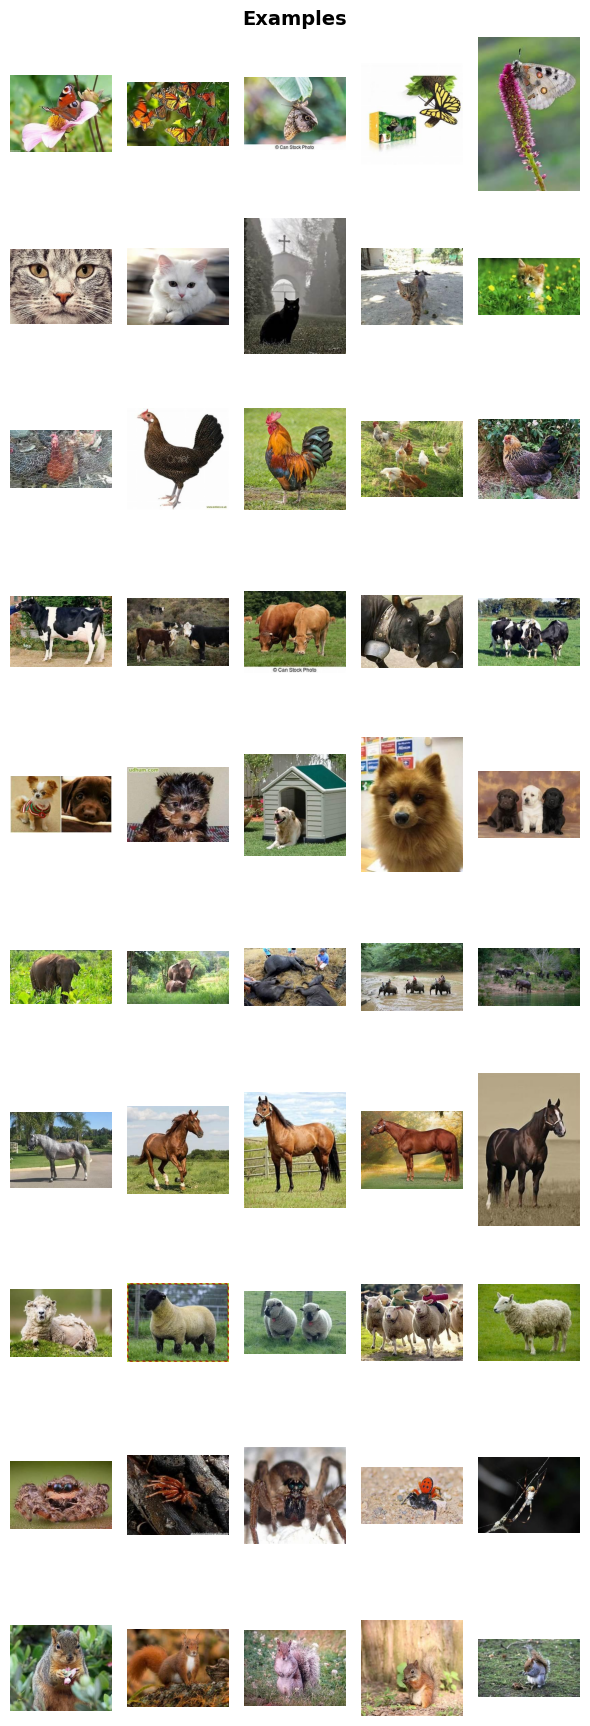

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(num_classes, 5, figsize=(6, 18))
fig.suptitle("Examples", fontsize=14, fontweight='bold')

for cls in range(num_classes):
    idxs = np.where(labels == cls)[0][:5]

    for col, idx in enumerate(idxs):
        ax = axes[cls][col]

        img = Image.open(df.iloc[idx]["filepath"])

        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(class_names[cls], fontsize=10, rotation=0, labelpad=30)

plt.tight_layout()
plt.show()

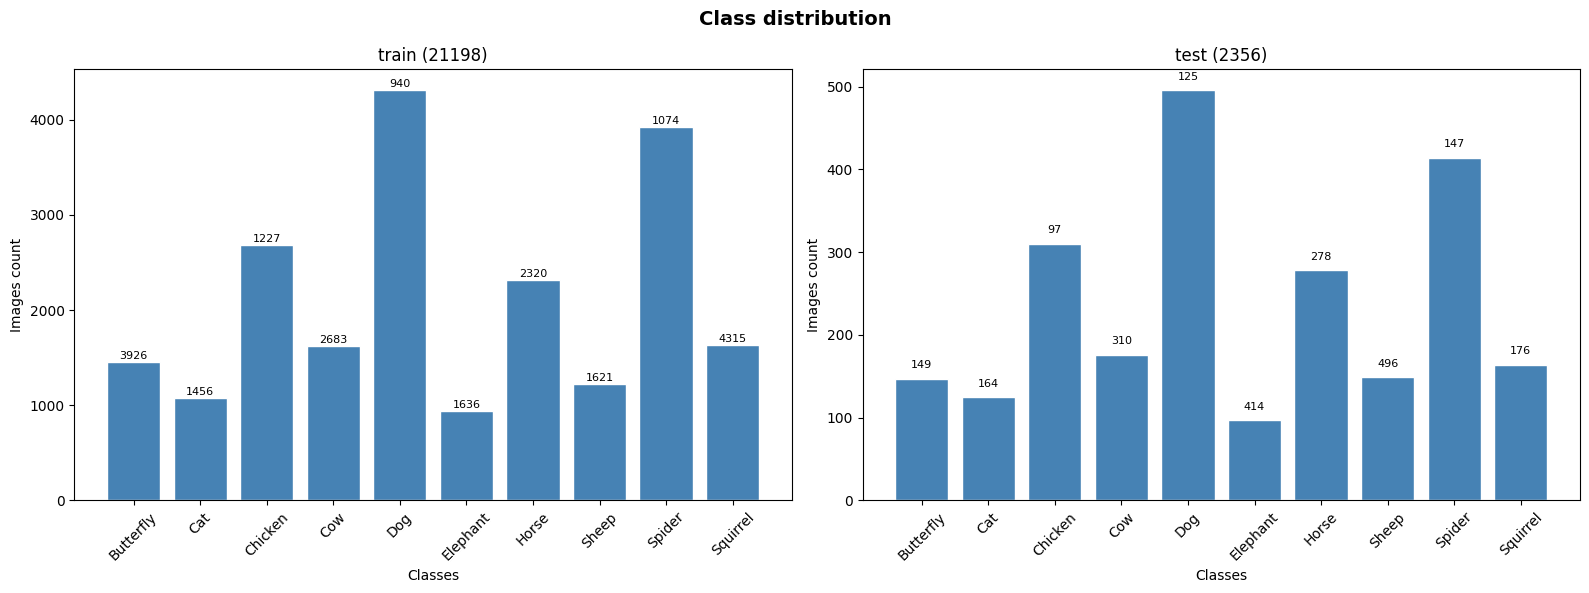

In [9]:
splits = df["split"].unique()

fig, axes = plt.subplots(1, len(splits), figsize=(16, 6))
fig.suptitle("Class distribution", fontsize=14, fontweight='bold')

for ax, split in zip(axes, splits):
    split_labels = df[df["split"] == split]["label_id"].values
    counts = Counter(split_labels)

    bars = ax.bar(
        counts.keys(),
        counts.values(),
        color='steelblue',
        edgecolor='white'
    )

    ax.set_title(f"{split} ({len(split_labels)})")
    ax.set_xlabel("Classes")
    ax.set_ylabel("Images count")
    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45)

    for bar, (cls, cnt) in zip(bars, sorted(counts.items())):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(cnt),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [10]:
for cls in range(num_classes):
    cnt = (labels == cls).sum()
    print(f"{class_names[cls]}: {cnt} ({cnt/len(labels)*100:.1f}%)")

Butterfly: 1603 (6.8%)
Cat: 1199 (5.1%)
Chicken: 2993 (12.7%)
Cow: 1797 (7.6%)
Dog: 4811 (20.4%)
Elephant: 1037 (4.4%)
Horse: 2598 (11.0%)
Sheep: 1376 (5.8%)
Spider: 4340 (18.4%)
Squirrel: 1800 (7.6%)


# Transformations and DataLoader for animal classification model
We have class imbalance, so we need to augment our dataset with transformations.

In [11]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [12]:
train_dataset = ImageFolder("./src/data/train", transform=train_transform)
test_dataset = ImageFolder("./src/data/test", transform=test_transform)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model training and evaluation
**Model:** ResNet18 pretrained \
**Criterion:** Cross Entropy Loss \
**Optimizer:** Adam

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [15]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/home/tym/projects/internship_test/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tym/projects/internship_test/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Train", leave=False)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    return total_loss / len(loader), correct / total

In [17]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Eval", leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{correct/total:.4f}"
            })

    return total_loss / len(loader), correct / total

In [19]:
epochs = 5

train_losses = []
test_losses = []

train_accs = []
test_accs = []

start_time = time.time()

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")

print(f"\nTrained for {time.time() - start_time:.2f} seconds")


Epoch 1/5


Train Loss: 0.3416 | Acc: 0.9003
Test  Loss: 0.1559 | Acc: 0.9489

Epoch 2/5


Train Loss: 0.2123 | Acc: 0.9290
Test  Loss: 0.1438 | Acc: 0.9473

Epoch 3/5


Train Loss: 0.2005 | Acc: 0.9335
Test  Loss: 0.1644 | Acc: 0.9418

Epoch 4/5


Train Loss: 0.1941 | Acc: 0.9345
Test  Loss: 0.1431 | Acc: 0.9510

Epoch 5/5


Train Loss: 0.1869 | Acc: 0.9378
Test  Loss: 0.1284 | Acc: 0.9553

Trained for 931.37 seconds


In [ ]:
save_path = "./src/artifacts/resnet18_animals.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)

## Results

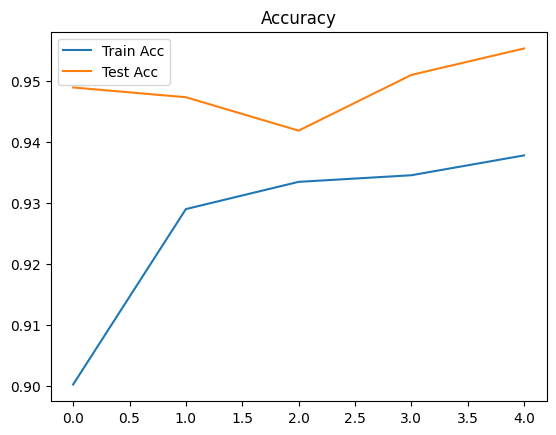

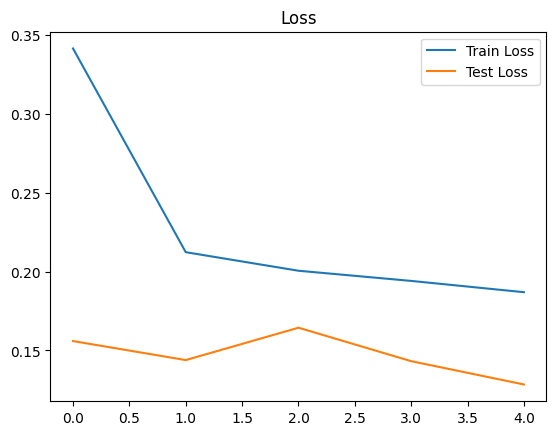

In [21]:
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss")
plt.show()

## Confusion matrix

In [22]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

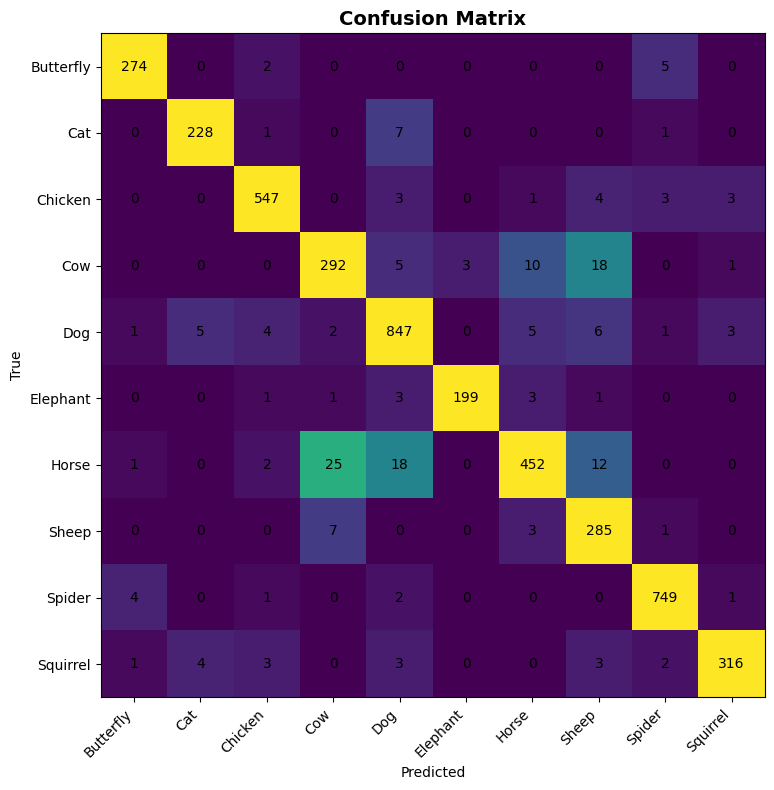

In [24]:
cm = confusion_matrix(all_labels, all_preds)


fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm, vmax=40)

ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()